In [4]:
### Prototype Explanation

# This prototype demonstrates how adaptive calibration can improve gaze prediction accuracy.

# - Initial model is trained on calibration data
# - Drift is simulated to represent real-world changes (lighting, movement)
# - Adaptive update retrains the model with new data

# Observation:
# - Error increases significantly after drift
# - Adaptive calibration reduces this error

# This supports the feasibility of a real-time adaptive calibration system.

Initial Error: 2364.1795305003693
Error after drift: 30967.866710746574
Error after adaptive update: 24280.09615657815


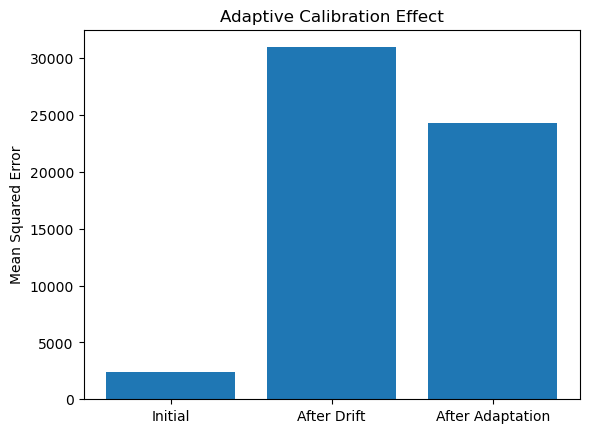

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


# 1. Generate synthetic calibration data


np.random.seed(42)

n_samples = 100

# iris features
left_iris_x = np.random.rand(n_samples)
right_iris_x = np.random.rand(n_samples)

# true screen coordinates (simple linear relation)
true_x = 800 * left_iris_x + 50 * np.random.randn(n_samples)
true_y = 600 * right_iris_x + 50 * np.random.randn(n_samples)

X = np.column_stack((left_iris_x, right_iris_x))


# 2. Train initial model (static calibration)


model = LinearRegression()
model.fit(X, true_x)

pred_initial = model.predict(X)
error_initial = mean_squared_error(true_x, pred_initial)

print("Initial Error:", error_initial)


# 3. Simulate drift (user movement, lighting)


drift = np.random.normal(0, 0.2, X.shape)
X_drifted = X + drift

pred_drifted = model.predict(X_drifted)
error_drifted = mean_squared_error(true_x, pred_drifted)

print("Error after drift:", error_drifted)


# 4. Adaptive update (retrain with new data)


# simulate new corrected data
X_adaptive = np.vstack((X, X_drifted))
y_adaptive = np.hstack((true_x, true_x))

model_adaptive = LinearRegression()
model_adaptive.fit(X_adaptive, y_adaptive)

pred_adaptive = model_adaptive.predict(X_drifted)
error_adaptive = mean_squared_error(true_x, pred_adaptive)

print("Error after adaptive update:", error_adaptive)


# 5. Visualization


labels = ["Initial", "After Drift", "After Adaptation"]
errors = [error_initial, error_drifted, error_adaptive]

plt.bar(labels, errors)
plt.title("Adaptive Calibration Effect")
plt.ylabel("Mean Squared Error")
plt.show()

In [6]:
print("\nImprovement:", error_drifted - error_adaptive)


Improvement: 6687.770554168423
